# Synthetic Dataset


Import libraries


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import ew_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [3]:
OUTPUT_FILE = "../../data/preprocessed/synthetic_dataset.csv"

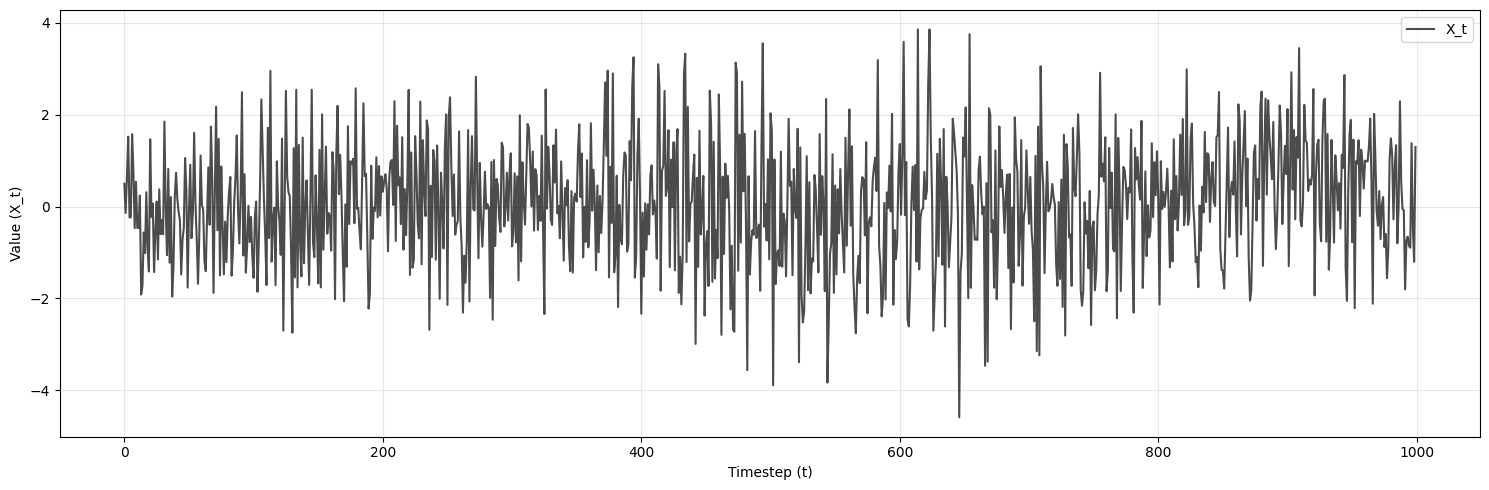

In [26]:
def generate_pdou(n_steps=10000, t_shift=5000, L1=20, L2=50, phi=0.7, sigma=1.0, seed=42):
    """
    Generates the Piecewise Delayed Ornstein-Uhlenbeck (P-DOU) dataset.

    Parameters:
    n_steps (int): Total length of the time series.
    t_shift (int): Timestep at which the structural concept drift occurs.
    L1 (int): The sparse lag dependency during the first regime.
    L2 (int): The sparse lag dependency during the second regime.
    phi (float): The discrete mean-reversion strength (autoregressive coefficient).
    sigma (float): The standard deviation of the Gaussian innovation noise.
    seed (int): Random seed for reproducibility.

    Returns:
    X (np.ndarray): The macroscopic visually coherent time series.
    Y (np.ndarray): The microscopic vacuum first-derivative series.
    """
    np.random.seed(seed)

    # Initialize the microscopic process Y and macroscopic process X arrays
    Y = np.zeros(n_steps)
    X = np.zeros(n_steps)

    # Generate identical and independently distributed (i.i.d.) innovation noise
    epsilon = np.random.normal(0, sigma, n_steps)

    # Define the maximum historical lag required for safe array initialization
    max_lag = max(L1, L2)

    # Populate the initial states purely with innovation noise
    Y[:max_lag] = epsilon[:max_lag]

    # Iterative state generation enforcing the microscopic vacuum
    for t in range(max_lag, n_steps):
        # Determine the operative regime's lag via the piecewise function
        current_lag = L1 if t < t_shift else L2

        # Calculate the delayed momentum state
        Y[t] = phi * Y[t - current_lag] + epsilon[t]

    # Integrate to achieve macroscopic visual coherence (I(1) transformation)
    X = np.cumsum(Y)

    return pd.DataFrame(X), pd.DataFrame(Y)


# ==========================================
# Execution & Verification
# ==========================================
if __name__ == "__main__":
    # Generate a standard test set
    _, synthetic_data = generate_pdou(n_steps=1000, t_shift=1000)

    # Visual verification of the structural shift
    plt.figure(figsize=(15, 5))
    plt.plot(synthetic_data, label="X_t", color="black", alpha=0.7)

    # Highlight the redundant regimes
    # plt.fill_between(
    #     synthetic_data.index,
    #     synthetic_data["value"].min(),
    #     synthetic_data["value"].max(),
    #     where=(synthetic_data["is_redundant"] == 1),
    #     color="red",
    #     alpha=0.2,
    #     label="Regime B (Redundant / High EW-ACF)",
    # )
    plt.xlabel("Timestep (t)")
    plt.ylabel("Value (X_t)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [27]:
time_series = synthetic_data
time_series.to_csv(OUTPUT_FILE, index=False)
time_series = time_series.to_numpy()

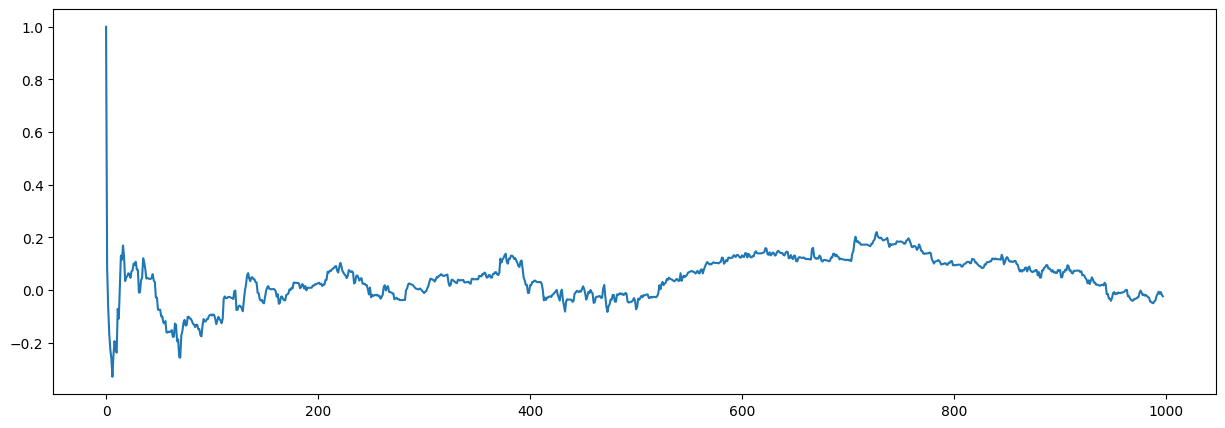

In [28]:
autocorr = ew_acf(time_series, lag=2, lambda_=0.99)
plt.figure(figsize=(15, 5))
plt.plot(autocorr)

### ACF


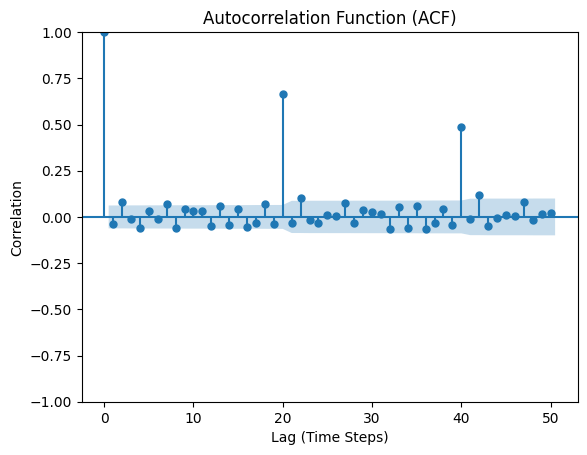

In [29]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF


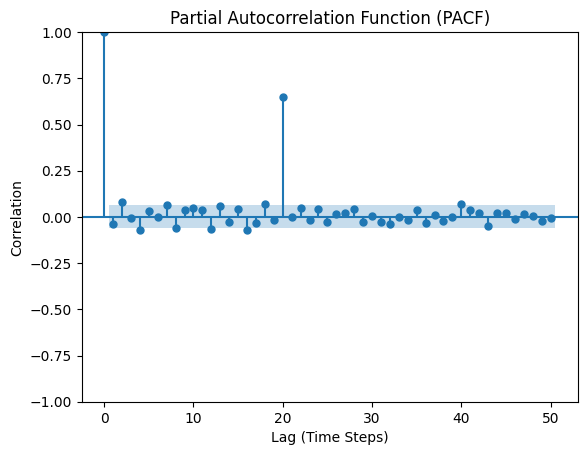

In [30]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 1.0398


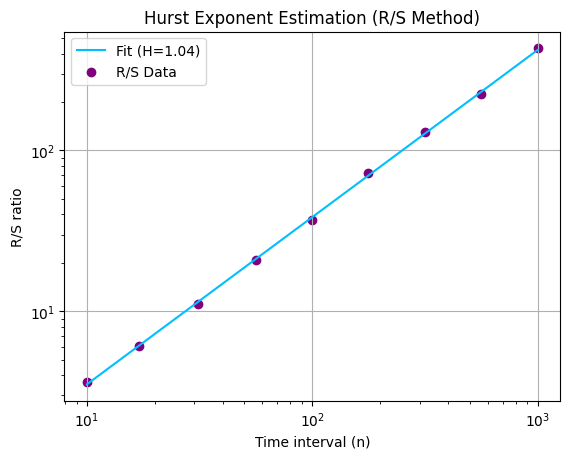

In [41]:
H, c, data = compute_Hc(time_series[2000:3000], kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()